# Assignment 4: Backmixing in tubular reactors

Benjamin Heuschmid, Kartik Nair, Saif Ullah


## 1. Introduction and Objective

A Plug Flow Reactor (PFR) is a theoretical model that is ideal without axial mixing. This model presents a simplified design and performance analysis of a reactor, but it does not account for non-ideal flow behaviour that is often found in real reactors. The mixing of fluid elements in the axial direction in real tubular reactors is known as axial dispersion or backmixing. This non-ideal mixing has the effect to change the residence time distribution of the reacting species, which is important to determine the conversion, selectivity and overall efficiency of the reactor. Therefore, a reliable modelling of axial dispersion is crucial to the design, optimization and scale up of industrial reactors [1, 2].

The axial dispersion model is one of the most popular models used to describe non-ideal flow behaviour. In this model, both convective transport and axial mixing are taken into account and more realistic performance of a tubular reactor can be obtained than for the ideal PFR model. The Bodenstein number (Bo), defined as the ratio of convective transport to axial dispersion is an important dimensionless number in this model. A high Bodenstein number means that backmixing is small and the reactor is closer to ideal plug flow behaviour, while a low Bodenstein number means that the axial mixing is larger and the deviation from the ideal PFR are bigger. Typically, the governing equations are solved using Boundary Value Problem (BVP) formulations with the Danckwerts boundary conditions, which are a physically consistent description of the mass transport at the boundary of the reactor inlet and outlet [2].

The reactor considered in this assignment has a length of 10 m and a diameter of 32 mm. It is fed from an upstream section with a diameter of 150 mm. The volumetric flow rate is 1 L/s , and the inlet contains component (A) with a concentration of 100 mol/m³.  Component (A) is converted to product (B). Boundary Value Problem (BVP) formulations are used for solving the governing equations of the axial dispersion model. In addition, the effect of the Bodenstein number on the concentration profile is studied and the results of the axial dispersion model are compared to those of an equivalent cascade of Continuous Stirred Tank Reactors (CSTRs) to determine the extent to which the former can be used to simulate non-ideal reactor behaviour.

## 2. Reactor data and model assumptions

The reactor considered in this assignment is a tubular reactor in which component A is converted into component B. For this implementation, the reaction is treated as irreversible and first order.

$$
\mathrm{A \rightarrow B}
$$

The reaction rate used in the code is:

$$
r = k c_A
$$

The reactor length is 10 m and the reactor diameter is 32 mm. The upstream pipe diameter is 150 mm. The volumetric flow rate is 1 L/s, which is converted to 0.001 m³/s in the code. The inlet concentration of component A is 100 mol/m³, while the inlet concentration of component B is set to 0 mol/m³.

The reactor cross-sectional area is calculated from the reactor diameter.

$$
A_R = \frac{\pi d_R^2}{4}
$$

The upstream pipe cross-sectional area is calculated in the same way.

$$
A_{up} = \frac{\pi d_{up}^2}{4}
$$

The superficial velocity in the reactor is calculated using the volumetric flow rate and the reactor cross-sectional area.

$$
u = \frac{\dot{V}}{A_R}
$$

The superficial velocity in the upstream pipe is calculated as:

$$
u_{up} = \frac{\dot{V}}{A_{up}}
$$

The mean residence time in the reactor is:

$$
\tau = \frac{L}{u}
$$

Using the values implemented in the code, the calculated reactor quantities are:

| Quantity | Symbol | Value | Unit |
|---|---:|---:|---|
| Reactor length | L | 10.0000 | m |
| Reactor diameter | d_R | 0.0320 | m |
| Upstream pipe diameter | d_up | 0.1500 | m |
| Volumetric flow rate | V_dot | 0.0010 | m³/s |
| Reactor cross-sectional area | A_R | 8.0425e-4 | m2 |
| Upstream cross-sectional area | A_up | 1.7671e-2 | m2 |
| Reactor superficial velocity | u | 1.2434 | m/s |
| Upstream superficial velocity | u_up | 0.0566 | m/s |
| Mean residence time | tau | 8.0425 | s |
| Inlet concentration of A | c_A,in | 100.0000 | mol/m³ |
| Inlet concentration of B | c_B,in | 0.0000 | mol/m³ |
| First-order rate constant | k | 0.2000 | 1/s |

The superficial velocity inside the reactor is much higher than the upstream velocity because the reactor diameter is significantly smaller than the upstream pipe diameter. Therefore, the same volumetric flow rate passes through a smaller cross-sectional area in the reactor.

The following assumptions are used in this model:

| Assumption | Meaning |
|---|---|
| Steady-state operation | Concentrations are independent of time. |
| Isothermal system | Temperature effects are not included in first model. |
| Irreversible first-order reaction | The reaction rate is proportional to the concentration of A. |
| Constant volumetric flow rate | Density and volume changes are neglected. |
| One-dimensional axial model | Concentration varies only along the reactor length z. |
| No radial concentration gradients | Radial mixing is assumed to be sufficient. |
| No side reactions | Only the conversion of A to B is considered. |
| Constant axial dispersion coefficient for each Bo | For each selected Bodenstein number, D_ax is constant along the reactor. |

The value k = 0.2 1/s is used as a reference value because no numerical value of the rate constant is specified in the task statement. This value gives an intermediate outlet conversion of about 0.80 in the ideal PFR. This makes it easier to compare ideal plug-flow behaviour, axial-dispersion behaviour and CSTR-cascade behaviour.

In [13]:
# Import
import numpy as np
import scipy.integrate as integ 
from scipy.integrate import solve_ivp, solve_bvp 
import matplotlib.pyplot as plt 
import pandas as pd

In [14]:
# Given reactor and feed data
L = 10.0                       # reactor length, m
d_R = 32e-3                    # reactor diameter, m
d_up = 150e-3                  # upstream pipe diameter, m
V_dot = 1.0e-3                 # volumetric flow rate, m3/s, from 1 L/s
c_A_in = 100.0                 # inlet concentration of A, mol/m3
c_B_in = 0.0                   # inlet concentration of B, mol/m3

# First implementation: first-order kinetics
# This value is selected as a reference value because the task statement does not provide k.
k = 0.2                        # rate constant, s^-1
reaction_order = 1.0

# Cross-sectional areas
A_R = np.pi * d_R**2 / 4
A_up = np.pi * d_up**2 / 4

# Superficial velocities
u = V_dot / A_R
u_up = V_dot / A_up

# Mean residence time in the reactor
tau = L / u


## 3. Ideal PFR model and solver validation

The ideal plug-flow reactor is first implemented as a reference model. In this model, axial dispersion and backmixing are neglected. The only transport mechanism along the reactor is convection, and the reaction takes place as the fluid moves through the reactor.

For the reaction:

$$
\mathrm{A \rightarrow B}
$$

and the first-order rate law:

$$
r = k c_A
$$

the material balance for component A is:

$$
u \frac{dc_A}{dz} = -k c_A
$$

The material balance for component B is:

$$
u \frac{dc_B}{dz} = k c_A
$$

These equations are solved as an initial value problem because the inlet concentrations are known at the beginning of the reactor.

$$
c_A(0) = c_{A,in}
$$

$$
c_B(0) = c_{B,in}
$$

In the code, this ideal PFR model is implemented in the function `pfr_ivp_rhs`. The function calculates the reaction rate and returns the derivatives of c_A and c_B with respect to the axial coordinate z. The system is solved numerically using `solve_ivp`.

For a first-order irreversible reaction in an ideal PFR, the concentration of A also has an analytical solution.

$$
c_A(z) = c_{A,in}\exp\left(-\frac{kz}{u}\right)
$$

The conversion of A is calculated as:

$$
X_A = \frac{c_{A,in} - c_A}{c_{A,in}}
$$

At the reactor outlet, the ideal PFR conversion can be written using the mean residence time.

$$
X_{A,out} = 1 - \exp(-k\tau)
$$

With the values used in the code:

$$
k = 0.2 \ \mathrm{s^{-1}}
$$

$$
\tau = 8.0425 \ \mathrm{s}
$$

The first-order Damköhler number is:

$$
Da_I = k \tau
$$

$$
Da_I = 0.2 \cdot 8.0425 = 1.6085
$$

Therefore, the ideal PFR outlet conversion is:

$$
X_{A,out} = 1 - \exp(-1.6085)
$$

$$
X_{A,out} \approx 0.7998
$$

The numerical result from the final summary gives:

| Quantity | Value |
|---|---:|
| c_A,out | 20.0189 mol/m3 |
| c_B,out | 79.9811 mol/m3 |
| X_A,out | 0.7998 |

The ideal PFR concentration profiles show that c_A decreases continuously along the reactor length, while c_B increases correspondingly. This is expected for the reaction A to B because the consumption of A directly forms B.

The numerical solution is then compared with the analytical solution for c_A. The plotted numerical and analytical curves overlap almost exactly. This confirms that the `solve_ivp` implementation, the first-order rate law and the material balances are consistent.

The conversion profile increases smoothly from zero at the inlet to approximately 0.80 at the outlet. This ideal PFR solution is used as the reference case for the later axial-dispersion model. In the limit of very high Bodenstein number, axial dispersion becomes very small, so the BVP solution should approach this ideal PFR result.

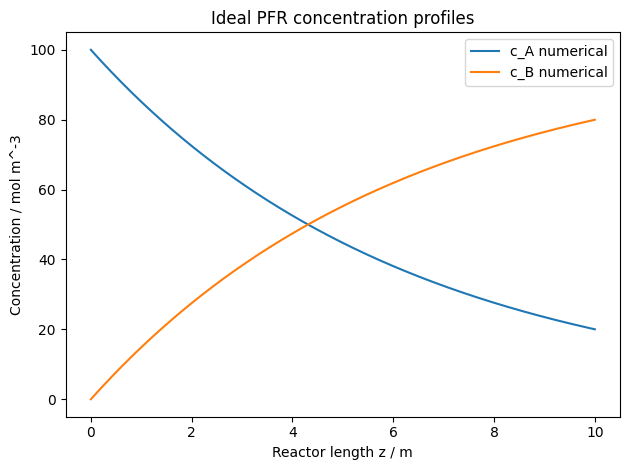

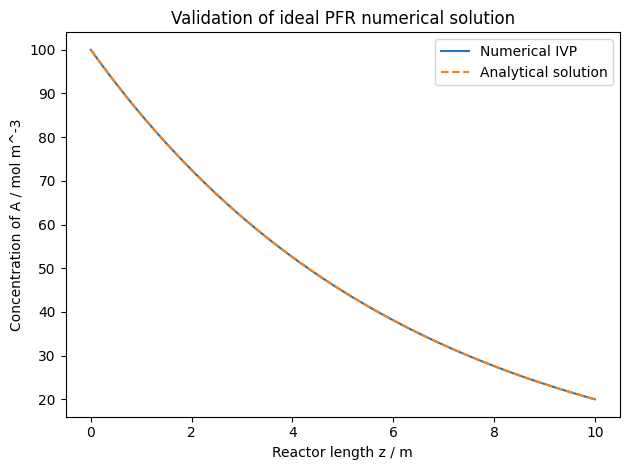

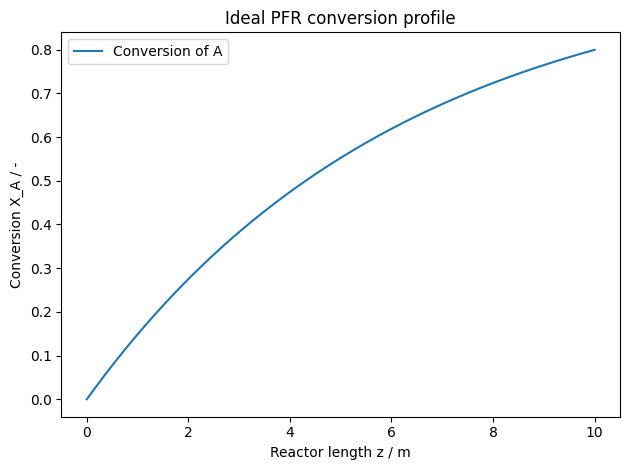

In [15]:
# Solver validation

# Function for conversion of component A
def conversion(c_A, c_A_in):
    """
    Calculate conversion of component A.
    
    Parameters
    ----------
    c_A : float or array
        Local concentration of component A.
    c_A_in : float
        Inlet concentration of component A.
        
    Returns
    -------
    X_A : float or array
        Conversion of component A.
    """
    return (c_A_in - c_A) / c_A_in

# Solution of the PFR ODE with IVP
def pfr_ivp_rhs(z, y, k, u):
    """
    Right-hand side of the ideal plug-flow reactor model.

    y[0] = c_A
    y[1] = c_B
    """
    c_A, c_B = y

    r = k * c_A

    dc_A_dz = -r / u
    dc_B_dz = r / u

    return [dc_A_dz, dc_B_dz]


# Axial grid for evaluation
z_eval = np.linspace(0, L, 500)

# Solve ideal PFR model
ivp_solution = solve_ivp(
    fun=lambda z, y: pfr_ivp_rhs(z, y, k, u),
    t_span=(0, L),
    y0=[c_A_in, c_B_in],
    t_eval=z_eval,
    method="RK45",
    rtol=1e-9,
    atol=1e-11
)

if not ivp_solution.success:
    raise RuntimeError(ivp_solution.message)

# Store results
pfr_df = pd.DataFrame({
    "z / m": ivp_solution.t,
    "c_A / mol m^-3": ivp_solution.y[0],
    "c_B / mol m^-3": ivp_solution.y[1],
})

pfr_df["X_A / -"] = conversion(pfr_df["c_A / mol m^-3"], c_A_in)

# Analytical solution
pfr_df["c_A analytical / mol m^-3"] = c_A_in * np.exp(-k * pfr_df["z / m"] / u)
pfr_df["X_A analytical / -"] = conversion(pfr_df["c_A analytical / mol m^-3"], c_A_in)

# Error between numerical and analytical solution
max_error_cA = np.max(
    np.abs(pfr_df["c_A / mol m^-3"] - pfr_df["c_A analytical / mol m^-3"])
)

max_error_X = np.max(
    np.abs(pfr_df["X_A / -"] - pfr_df["X_A analytical / -"])
)

# Summary table
pfr_summary = pd.DataFrame([
    {
        "Model": "Ideal PFR IVP",
        "Residence time / s": tau,
        "c_A,out / mol m^-3": pfr_df["c_A / mol m^-3"].iloc[-1],
        "c_B,out / mol m^-3": pfr_df["c_B / mol m^-3"].iloc[-1],
        "X_A,out / -": pfr_df["X_A / -"].iloc[-1],
        "Max. error c_A / mol m^-3": max_error_cA,
        "Max. error X_A / -": max_error_X,
    }
])


# Concentration profiles
plt.figure()
plt.plot(
    pfr_df["z / m"],
    pfr_df["c_A / mol m^-3"],
    label="c_A numerical"
)
plt.plot(
    pfr_df["z / m"],
    pfr_df["c_B / mol m^-3"],
    label="c_B numerical"
)
plt.xlabel("Reactor length z / m")
plt.ylabel("Concentration / mol m^-3")
plt.title("Ideal PFR concentration profiles")
plt.legend()
plt.tight_layout()
plt.show()

# Numerical vs analytical validation
plt.figure()
plt.plot(
    pfr_df["z / m"],
    pfr_df["c_A / mol m^-3"],
    label="Numerical IVP"
)
plt.plot(
    pfr_df["z / m"],
    pfr_df["c_A analytical / mol m^-3"],
    "--",
    label="Analytical solution"
)
plt.xlabel("Reactor length z / m")
plt.ylabel("Concentration of A / mol m^-3")
plt.title("Validation of ideal PFR numerical solution")
plt.legend()
plt.tight_layout()
plt.show()

# Conversion profile
plt.figure()
plt.plot(
    pfr_df["z / m"],
    pfr_df["X_A / -"],
    label="Conversion of A"
)
plt.xlabel("Reactor length z / m")
plt.ylabel("Conversion X_A / -")
plt.title("Ideal PFR conversion profile")
plt.legend()
plt.tight_layout()
plt.show()

## 4. Axial-dispersion BVP model

After validating the ideal PFR model, axial dispersion is included in the reactor model. In contrast to the ideal PFR, the axial-dispersion model accounts for backmixing in the axial direction. Therefore, the concentration profile is influenced by convection, reaction and axial dispersion.

For a general component i, the axial-dispersion balance can be written as:

$$
u \frac{dc_i}{dz}
=
D_{ax}\frac{d^2c_i}{dz^2}
+
\sum_j \nu_{i,j} r_j
$$

For the reaction:

$$
\mathrm{A \rightarrow B}
$$

with first-order kinetics:

$$
r = k c_A
$$

the balance for component A becomes:

$$
u \frac{dc_A}{dz}
=
D_{ax}\frac{d^2c_A}{dz^2}
-
k c_A
$$

The balance for component B becomes:

$$
u \frac{dc_B}{dz}
=
D_{ax}\frac{d^2c_B}{dz^2}
+
k c_A
$$

The axial-dispersion model contains second derivatives with respect to the reactor coordinate z. Therefore, it cannot be solved only from inlet initial values. Instead, boundary conditions are required at both the inlet and the outlet. For this reason, the axial-dispersion model is implemented as a boundary value problem using `solve_bvp`.

To solve the second-order differential equations with `solve_bvp`, the model is rewritten as a first-order system. The following variables are introduced:

$$
y_0 = c_A
$$

$$
y_1 = \frac{dc_A}{dz}
$$

$$
y_2 = c_B
$$

$$
y_3 = \frac{dc_B}{dz}
$$

The corresponding first-order system is:

$$
\frac{dy_0}{dz} = y_1
$$

$$
\frac{dy_1}{dz}
=
\frac{u y_1 + k y_0}{D_{ax}}
$$

$$
\frac{dy_2}{dz} = y_3
$$

$$
\frac{dy_3}{dz}
=
\frac{u y_3 - k y_0}{D_{ax}}
$$

This is exactly the structure implemented in the function `dispersion_bvp_rhs`. The function returns the first derivatives of the four state variables with respect to the axial coordinate.

The axial dispersion coefficient is related to the Bodenstein number by:

$$
Bo = \frac{uL}{D_{ax}}
$$

Therefore:

$$
D_{ax} = \frac{uL}{Bo}
$$

A high Bodenstein number corresponds to a small axial dispersion coefficient. This means that convective transport dominates and the reactor approaches ideal plug-flow behaviour. A low Bodenstein number corresponds to a larger axial dispersion coefficient, meaning stronger axial backmixing and stronger deviation from the ideal PFR.

The inlet boundary condition is written as a Danckwerts boundary condition. For component A:

$$
c_A(0) - \frac{D_{ax}}{u}\frac{dc_A}{dz}\bigg|_{z=0}
=
c_{A,in}
$$

For component B:

$$
c_B(0) - \frac{D_{ax}}{u}\frac{dc_B}{dz}\bigg|_{z=0}
=
c_{B,in}
$$

At the reactor outlet, a zero-gradient boundary condition is applied:

$$
\frac{dc_A}{dz}\bigg|_{z=L} = 0
$$

$$
\frac{dc_B}{dz}\bigg|_{z=L} = 0
$$

The Danckwerts inlet condition allows the concentration directly inside the reactor at z = 0 to differ from the feed concentration. This difference is caused by axial dispersion and is later evaluated as the inlet concentration jump. The outlet zero-gradient condition assumes that there is no further axial concentration gradient at the reactor exit.

In the code, these four boundary conditions are implemented in the function `dispersion_bc`. Together, `dispersion_bvp_rhs` and `dispersion_bc` define the complete axial-dispersion BVP.

## 5. High-Bodenstein-number validation of the BVP

To validate the axial-dispersion BVP implementation, the model is first solved at a very high Bodenstein number.

$$
Bo = 10000
$$

The axial dispersion coefficient is calculated from:

$$
D_{ax} = \frac{uL}{Bo}
$$

Since the Bodenstein number is very large, the axial dispersion coefficient becomes very small. Physically, this means that convective transport dominates over axial backmixing. Therefore, the axial-dispersion model should approach the ideal PFR model.

In the code, the BVP solution at \(Bo = 10000\) is compared with the ideal PFR IVP solution for \(c_A\), \(c_B\), and \(X_A\). The concentration profile of component A from the dispersion model overlaps almost exactly with the ideal PFR result. The same behaviour is observed for component B. This confirms that the axial-dispersion model correctly approaches the plug-flow limit when axial dispersion becomes negligible.

The conversion profiles also overlap almost completely. The relative difference in outlet conversion between the high-Bodenstein-number BVP and the ideal PFR IVP is:

$$
\mathrm{relative \ difference} = 0.01\%
$$

This very small difference shows that the BVP implementation is numerically consistent with the ideal PFR model in the high-\(Bo\) limit.

The Danckwerts inlet boundary condition also causes a small difference between the feed concentration and the concentration directly inside the reactor at \(z = 0\). From the code output:

| Quantity | Value |
|---|---:|
| Feed concentration \(c_{A,in}\) | 100.0000 mol/m3 |
| In-reactor inlet concentration \(c_A(z=0)\) | 99.9839 mol/m3 |
| Inlet concentration jump | 0.0161 mol/m3 |
| Relative inlet concentration jump | 0.02% |

The inlet concentration jump is very small because \(Bo = 10000\) corresponds to weak axial dispersion. This is expected, because in the ideal plug-flow limit there should be no significant backmixing at the inlet.

Overall, the high-\(Bo\) validation confirms that the axial-dispersion BVP is implemented correctly. When axial dispersion is made very small, the BVP result approaches the ideal PFR result for both concentration and conversion profiles.

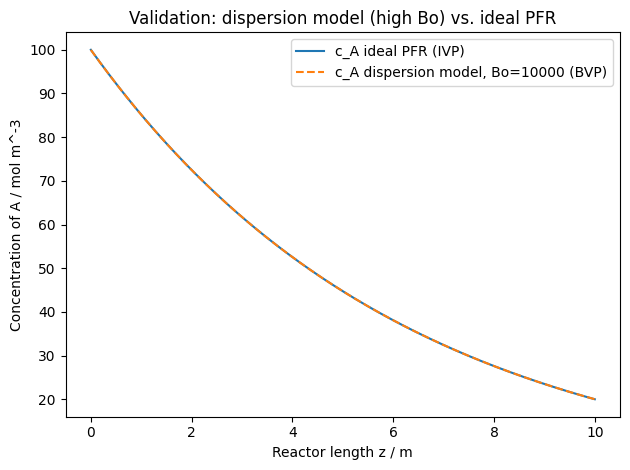

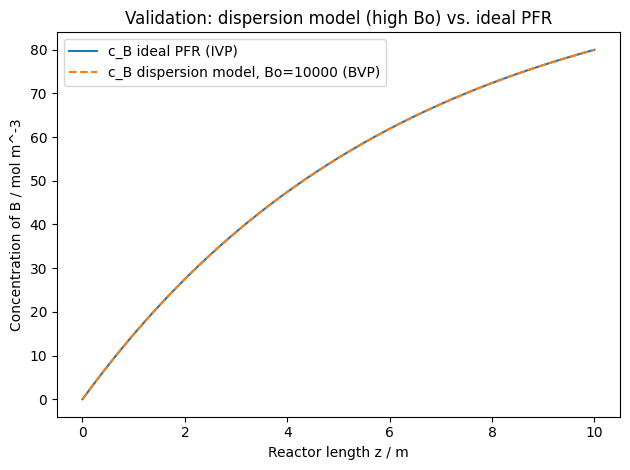

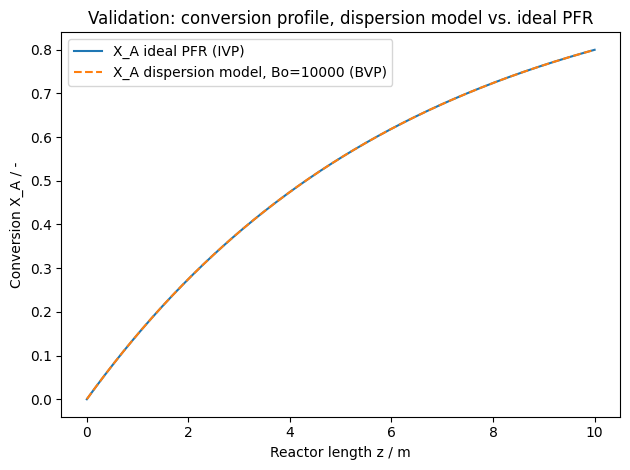

c_A,in (feed)        = 100.0000 mol/m^3
c_A(z=0) (in-reactor) = 99.9839 mol/m^3
Inlet concentration jump = 0.0161 mol/m^3  (0.02%)
Relative difference in outlet conversion: 0.01%


In [16]:
# Boundary value problem

# Solution of ODE with BVP for axial-dispersion model
def dispersion_bvp_rhs(z, y, k, u, D_ax):
    """
    Right-hand side of the axial-dispersion model, first-order system.

    y[0] = c_A
    y[1] = dc_A/dz
    y[2] = c_B
    y[3] = dc_B/dz
    """
    c_A, dcA_dz, c_B, dcB_dz = y

    # from  u*dcA/dz = D_ax*d2cA/dz2 - k*c_A
    d2cA_dz2 = (u * dcA_dz + k * c_A) / D_ax

    # from  u*dcB/dz = D_ax*d2cB/dz2 + k*c_A
    d2cB_dz2 = (u * dcB_dz - k * c_A) / D_ax

    return np.vstack((dcA_dz, d2cA_dz2, dcB_dz, d2cB_dz2))

# Boundary conditions for the BVP
def dispersion_bc(ya, yb, c_A_in, c_B_in, u, D_ax):
    """
    Danckwerts boundary conditions at z=0 and z=L for both species.
    """
    cA0, dcA0, cB0, dcB0 = ya   # state at z=0
    cAL, dcAL, cBL, dcBL = yb   # state at z=L

    # z = 0: Danckwerts inlet condition
    res_A0 = cA0 - (D_ax / u) * dcA0 - c_A_in
    res_B0 = cB0 - (D_ax / u) * dcB0 - c_B_in

    # z = L: zero-gradient outlet condition
    res_AL = dcAL
    res_BL = dcBL

    return np.array([res_A0, res_AL, res_B0, res_BL])

# High Bo for the first validation run
Bo_high = 1e4
D_ax = u * L / Bo_high

# Mesh and initial guess
z_mesh = np.linspace(0, L, 200)
y_guess = np.zeros((4, z_mesh.size))
y_guess[0] = c_A_in                 # rough guess: c_A starts near inlet value
y_guess[2] = 0.0                    # rough guess: c_B starts at 0

bvp_solution = solve_bvp(
    lambda z, y: dispersion_bvp_rhs(z, y, k, u, D_ax),
    lambda ya, yb: dispersion_bc(ya, yb, c_A_in, c_B_in, u, D_ax),
    z_mesh,
    y_guess
)

if not bvp_solution.success:
    raise RuntimeError(bvp_solution.message)

z_plot = np.linspace(0, L, 500)
y_plot = bvp_solution.sol(z_plot)
c_A_bvp = y_plot[0]
c_B_bvp = y_plot[2]

# Comparison: axial-dispersion BVP (high Bo) vs ideal PFR IVP
plt.figure()
plt.plot(
    pfr_df["z / m"],
    pfr_df["c_A / mol m^-3"],
    label="c_A ideal PFR (IVP)"
)
plt.plot(
    z_plot,
    c_A_bvp,
    "--",
    label=f"c_A dispersion model, Bo={Bo_high:.0f} (BVP)"
)
plt.xlabel("Reactor length z / m")
plt.ylabel("Concentration of A / mol m^-3")
plt.title("Validation: dispersion model (high Bo) vs. ideal PFR")
plt.legend()
plt.tight_layout()
plt.show()

# Same comparison for component B
plt.figure()
plt.plot(
    pfr_df["z / m"],
    pfr_df["c_B / mol m^-3"],
    label="c_B ideal PFR (IVP)"
)
plt.plot(
    z_plot,
    c_B_bvp,
    "--",
    label=f"c_B dispersion model, Bo={Bo_high:.0f} (BVP)"
)
plt.xlabel("Reactor length z / m")
plt.ylabel("Concentration of B / mol m^-3")
plt.title("Validation: dispersion model (high Bo) vs. ideal PFR")
plt.legend()
plt.tight_layout()
plt.show()

# Conversion comparison and quantitative error at outlet
X_A_bvp = conversion(c_A_bvp, c_A_in)

plt.figure()
plt.plot(
    pfr_df["z / m"],
    pfr_df["X_A / -"],
    label="X_A ideal PFR (IVP)"
)
plt.plot(
    z_plot,
    X_A_bvp,
    "--",
    label=f"X_A dispersion model, Bo={Bo_high:.0f} (BVP)"
)
plt.xlabel("Reactor length z / m")
plt.ylabel("Conversion X_A / -")
plt.title("Validation: conversion profile, dispersion model vs. ideal PFR")
plt.legend()
plt.tight_layout()
plt.show()

# Quantitative check at the outlet
X_A_out_ivp = pfr_df["X_A / -"].iloc[-1]
X_A_out_bvp = X_A_bvp[-1]
rel_diff = abs(X_A_out_bvp - X_A_out_ivp) / X_A_out_ivp

validation_summary = pd.DataFrame([{
    "Model": "Ideal PFR (IVP)",
    "Bo": np.inf,
    "X_A,out / -": X_A_out_ivp,
}, {
    "Model": "Dispersion model (BVP)",
    "Bo": Bo_high,
    "X_A,out / -": X_A_out_bvp,
}])

c_A_inlet_bvp = bvp_solution.sol(0)[0]   # c_A at z = 0, inside the reactor
c_A_jump = c_A_in - c_A_inlet_bvp
c_A_jump_rel = c_A_jump / c_A_in

print(f"c_A,in (feed)        = {c_A_in:.4f} mol/m^3")
print(f"c_A(z=0) (in-reactor) = {c_A_inlet_bvp:.4f} mol/m^3")
print(f"Inlet concentration jump = {c_A_jump:.4f} mol/m^3  ({c_A_jump_rel:.2%})")
print(f"Relative difference in outlet conversion: {rel_diff:.2%}")

## 6. Inlet concentration jump for different Bodenstein numbers

The Danckwerts inlet boundary condition allows the concentration directly inside the reactor at \(z = 0\) to be different from the feed concentration. This difference is called the inlet concentration jump.

For component A, the Danckwerts inlet condition is:

$$
c_A(0) - \frac{D_{ax}}{u}\frac{dc_A}{dz}\bigg|_{z=0}
=
c_{A,in}
$$

Therefore, if axial dispersion is significant, the concentration inside the reactor at the inlet does not have to be exactly equal to the feed concentration. This is a characteristic feature of the axial-dispersion model and does not occur in the ideal PFR model.

In the code, the inlet concentration jump is calculated for three different Bodenstein numbers:

$$
Bo = 100,\ 1000,\ 10000
$$

The results are:

| Bo | c_A(z=0) / mol/m³ | Inlet jump / % |
|---:|---:|---:|
| 100 | 98.4413 | 1.5587 |
| 1000 | 99.8397 | 0.1603 |
| 10000 | 99.9839 | 0.0161 |

The results show that the inlet concentration jump decreases strongly as the Bodenstein number increases. At \(Bo = 100\), the concentration directly inside the reactor is 98.4413 mol/m³, giving an inlet jump of 1.5587%. At \(Bo = 10000\), the concentration inside the reactor is almost equal to the feed concentration, and the inlet jump is only 0.0161%.

This behaviour is physically reasonable because a larger Bodenstein number corresponds to weaker axial dispersion. When axial dispersion is weak, the reactor behaves more like an ideal PFR and the inlet concentration inside the reactor approaches the feed concentration. When the Bodenstein number is lower, axial backmixing becomes stronger, and the difference between the feed concentration and the in-reactor inlet concentration becomes larger.

Thus, the inlet concentration jump provides a useful numerical indicator of the strength of axial backmixing in the Danckwerts boundary condition.

In [17]:
# Differences in inlet concentration jump for different Bo numbers

bo_values = [1e2, 1e3, 1e4]
jump_records = []

for Bo in bo_values:
    D_ax_i = u * L / Bo
    sol_i = solve_bvp(
        lambda z, y: dispersion_bvp_rhs(z, y, k, u, D_ax_i),
        lambda ya, yb: dispersion_bc(ya, yb, c_A_in, c_B_in, u, D_ax_i),
        z_mesh, y_guess
    )
    c_A0_i = sol_i.sol(0)[0]
    jump_records.append({
        "Bo": Bo,
        "c_A(z=0) / mol m^-3": c_A0_i,
        "Inlet jump / %": (c_A_in - c_A0_i) / c_A_in * 100
    })

print(pd.DataFrame(jump_records))

        Bo  c_A(z=0) / mol m^-3  Inlet jump / %
0    100.0            98.441258        1.558742
1   1000.0            99.839666        0.160334
2  10000.0            99.983920        0.016080


## 7. Full Bodenstein-number study

After the inlet-jump check, the influence of axial dispersion is investigated over a wider range of Bodenstein numbers. The values used in the code are:

$$
Bo = 5,\ 10,\ 20,\ 50,\ 100,\ 1000,\ 10000
$$

For each Bodenstein number, the axial dispersion coefficient is calculated using:

$$
D_{ax} = \frac{uL}{Bo}
$$

Therefore, a low Bodenstein number corresponds to a high axial dispersion coefficient, while a high Bodenstein number corresponds to a low axial dispersion coefficient.

The calculated results are:

| Bo | D_ax / m2/s | c_A(z=0) / mol/m³ | Inlet jump / % | c_A,out / mol/m³ | c_B,out / mol/m³ | X_A,out |
|---:|---:|---:|---:|---:|---:|---:|
| 5 | 2.4868 | 79.6212 | 20.3788 | 26.6341 | 73.3659 | 0.7337 |
| 10 | 1.2434 | 87.6443 | 12.3557 | 24.0475 | 75.9525 | 0.7595 |
| 20 | 0.6217 | 93.0383 | 6.9617 | 22.2823 | 77.7177 | 0.7772 |
| 50 | 0.2487 | 96.9747 | 3.0253 | 20.9979 | 79.0021 | 0.7900 |
| 100 | 0.1243 | 98.4413 | 1.5587 | 20.5221 | 79.4779 | 0.7948 |
| 1000 | 0.0124 | 99.8397 | 0.1603 | 20.0705 | 79.9295 | 0.7993 |
| 10000 | 0.0012 | 99.9839 | 0.0161 | 20.0240 | 79.9760 | 0.7998 |

The results show that the outlet conversion increases as the Bodenstein number increases. At \(Bo = 5\), the outlet conversion is 0.7337. At \(Bo = 10000\), the outlet conversion is 0.7998, which is almost identical to the ideal PFR conversion. This confirms that the axial-dispersion model approaches ideal plug-flow behaviour when the Bodenstein number becomes very large.

The concentration profiles also show the effect of axial dispersion. For low Bodenstein numbers, the concentration of A at the reactor inlet is already significantly lower than the feed concentration. For example, at \(Bo = 5\), the in-reactor inlet concentration is only 79.6212 mol/m3. This is caused by strong axial backmixing and the Danckwerts inlet boundary condition.

As the Bodenstein number increases, the \(c_A\) profile becomes closer to the ideal PFR profile. At \(Bo = 10000\), the axial-dispersion profile almost overlaps with the ideal PFR profile. The same trend is observed for component B and for the conversion profile.

The outlet-conversion plot shows that the strongest change occurs at low Bodenstein numbers. Increasing \(Bo\) from 5 to 100 causes a clear increase in outlet conversion. However, increasing \(Bo\) further from 1000 to 10000 causes only a very small change. This means that once axial dispersion becomes sufficiently small, the reactor behaviour is already close to the ideal PFR limit.

The inlet concentration jump also decreases strongly with increasing \(Bo\). At \(Bo = 5\), the inlet jump is 20.3788%, while at \(Bo = 10000\), it is only 0.0161%. This confirms that lower \(Bo\) values represent stronger backmixing at the reactor inlet.

The dispersive flux of A is calculated in the code as:

$$
J_{disp,A} = -D_{ax}\frac{dc_A}{dz}
$$

The maximum absolute dispersive flux is highest at low Bodenstein number. The output shows that the maximum value decreases from 25.3390 mol/m2/s at \(Bo = 5\) to only 0.0200 mol/m2/s at \(Bo = 10000\). In all cases, the maximum dispersive flux occurs at \(z = 0\). This is reasonable because the concentration gradient is strongest near the reactor inlet.

Overall, the Bodenstein-number study shows that axial dispersion reduces the plug-flow character of the reactor. Stronger axial dispersion, represented by lower \(Bo\), causes a larger inlet concentration jump, stronger dispersive flux and lower outlet conversion. Higher \(Bo\) values reduce these effects and move the reactor behaviour closer to the ideal PFR.

Full Bodenstein-number study:
 Bo / -  D_ax / m2 s^-1  c_A(z=0) / mol m^-3  Inlet jump / %  c_A,out / mol m^-3  c_B,out / mol m^-3  X_A,out / -  max |J_disp,A| / mol m^-2 s^-1  z at max |J_disp,A| / m
      5        2.486796            79.621166       20.378834           26.634107           73.365893     0.733659                       25.339001                      0.0
     10        1.243398            87.644337       12.355663           24.047512           75.952488     0.759525                       15.363007                      0.0
     20        0.621699            93.038327        6.961673           22.282345           77.717655     0.777177                        8.656130                      0.0
     50        0.248680            96.974711        3.025289           20.997864           79.002136     0.790021                        3.761638                      0.0
    100        0.124340            98.441258        1.558742           20.522135           79.477865     0.794779  

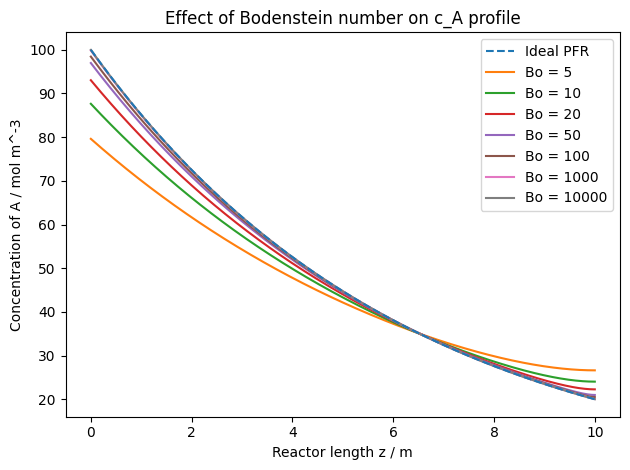

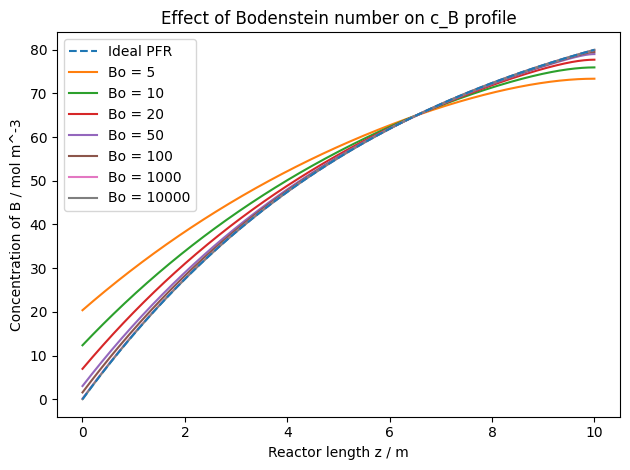

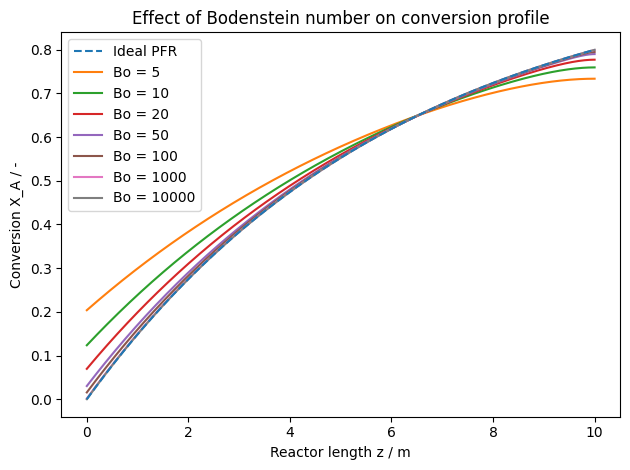

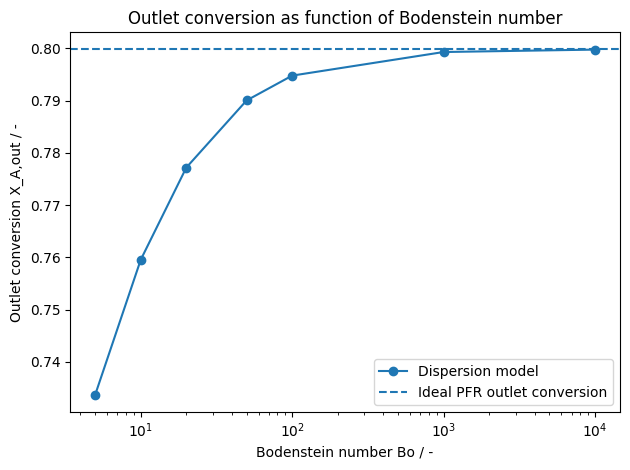

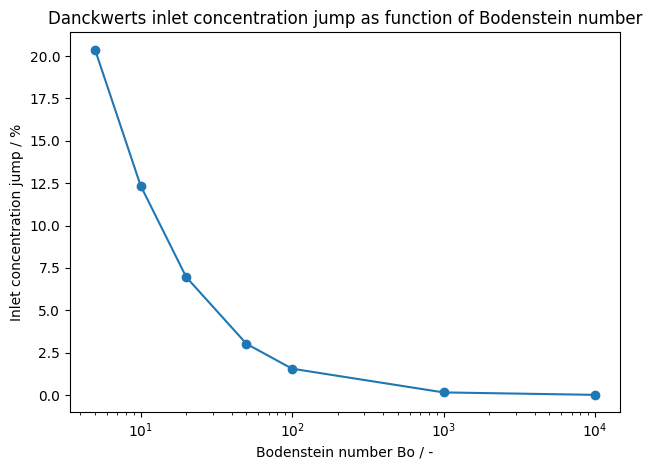

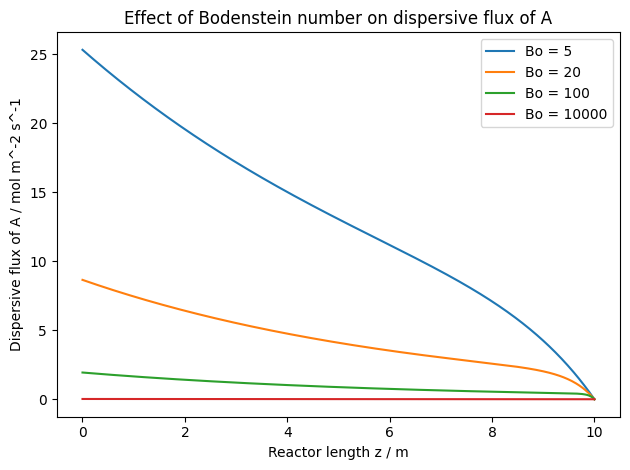

In [18]:
# Full Bodenstein-number study for axial dispersion and backmixing

bo_study_values = [5, 10, 20, 50, 100, 1000, 10000]
bo_results = {}
bo_summary_records = []

z_bvp_study = np.linspace(0, L, 500)

for Bo in bo_study_values:
    D_ax_i = u * L / Bo

    z_mesh_i = np.linspace(0, L, 300)

    c_A_guess = c_A_in * np.exp(-k * z_mesh_i / u)
    dcA_dz_guess = -(k / u) * c_A_guess
    c_B_guess = c_B_in + c_A_in - c_A_guess
    dcB_dz_guess = -dcA_dz_guess

    y_guess_i = np.vstack((c_A_guess, dcA_dz_guess, c_B_guess, dcB_dz_guess))

    sol_i = solve_bvp(
        lambda z, y: dispersion_bvp_rhs(z, y, k, u, D_ax_i),
        lambda ya, yb: dispersion_bc(ya, yb, c_A_in, c_B_in, u, D_ax_i),
        z_mesh_i,
        y_guess_i,
        tol=1e-5,
        max_nodes=20000
    )

    if not sol_i.success:
        print(f"BVP failed for Bo = {Bo}: {sol_i.message}")
        continue

    y_i = sol_i.sol(z_bvp_study)

    c_A_i = y_i[0]
    dcA_dz_i = y_i[1]
    c_B_i = y_i[2]
    dcB_dz_i = y_i[3]
    X_A_i = conversion(c_A_i, c_A_in)

    c_A0_i = sol_i.sol(0)[0]
    inlet_jump_i = c_A_in - c_A0_i
    inlet_jump_percent_i = inlet_jump_i / c_A_in * 100

    J_disp_A_i = -D_ax_i * dcA_dz_i
    max_abs_J_disp_A_i = np.max(np.abs(J_disp_A_i))
    z_max_J_i = z_bvp_study[np.argmax(np.abs(J_disp_A_i))]

    bo_results[Bo] = {
        "solution": sol_i,
        "D_ax": D_ax_i,
        "z": z_bvp_study,
        "c_A": c_A_i,
        "dcA_dz": dcA_dz_i,
        "c_B": c_B_i,
        "dcB_dz": dcB_dz_i,
        "X_A": X_A_i,
        "J_disp_A": J_disp_A_i
    }

    bo_summary_records.append({
        "Bo / -": Bo,
        "D_ax / m2 s^-1": D_ax_i,
        "c_A(z=0) / mol m^-3": c_A0_i,
        "Inlet jump / %": inlet_jump_percent_i,
        "c_A,out / mol m^-3": c_A_i[-1],
        "c_B,out / mol m^-3": c_B_i[-1],
        "X_A,out / -": X_A_i[-1],
        "max |J_disp,A| / mol m^-2 s^-1": max_abs_J_disp_A_i,
        "z at max |J_disp,A| / m": z_max_J_i
    })

bo_summary_df = pd.DataFrame(bo_summary_records)

print("Full Bodenstein-number study:")
print(bo_summary_df.to_string(index=False))

# Concentration of A for different Bo
plt.figure()
plt.plot(
    pfr_df["z / m"],
    pfr_df["c_A / mol m^-3"],
    "--",
    zorder=10,
    label="Ideal PFR"
)

for Bo in bo_study_values:
    if Bo in bo_results:
        plt.plot(
            bo_results[Bo]["z"],
            bo_results[Bo]["c_A"],
            label=f"Bo = {Bo:g}"
        )

plt.xlabel("Reactor length z / m")
plt.ylabel("Concentration of A / mol m^-3")
plt.title("Effect of Bodenstein number on c_A profile")
plt.legend()
plt.tight_layout()
plt.show()

# Concentration of B for different Bo
plt.figure()
plt.plot(
    pfr_df["z / m"],
    pfr_df["c_B / mol m^-3"],
    "--",
    zorder=10,
    label="Ideal PFR"
)

for Bo in bo_study_values:
    if Bo in bo_results:
        plt.plot(
            bo_results[Bo]["z"],
            bo_results[Bo]["c_B"],
            label=f"Bo = {Bo:g}"
        )

plt.xlabel("Reactor length z / m")
plt.ylabel("Concentration of B / mol m^-3")
plt.title("Effect of Bodenstein number on c_B profile")
plt.legend()
plt.tight_layout()
plt.show()

# Conversion for different Bo
plt.figure()
plt.plot(
    pfr_df["z / m"],
    pfr_df["X_A / -"],
    "--",
    zorder=10,
    label="Ideal PFR"
)

for Bo in bo_study_values:
    if Bo in bo_results:
        plt.plot(
            bo_results[Bo]["z"],
            bo_results[Bo]["X_A"],
            label=f"Bo = {Bo:g}"
        )

plt.xlabel("Reactor length z / m")
plt.ylabel("Conversion X_A / -")
plt.title("Effect of Bodenstein number on conversion profile")
plt.legend()
plt.tight_layout()
plt.show()

# Outlet conversion as function of Bo
plt.figure()
plt.semilogx(
    bo_summary_df["Bo / -"],
    bo_summary_df["X_A,out / -"],
    marker="o",
    label="Dispersion model"
)
plt.axhline(
    y=pfr_df["X_A / -"].iloc[-1],
    linestyle="--",
    label="Ideal PFR outlet conversion"
)
plt.xlabel("Bodenstein number Bo / -")
plt.ylabel("Outlet conversion X_A,out / -")
plt.title("Outlet conversion as function of Bodenstein number")
plt.legend()
plt.tight_layout()
plt.show()

# Inlet concentration jump as function of Bo
plt.figure()
plt.semilogx(
    bo_summary_df["Bo / -"],
    bo_summary_df["Inlet jump / %"],
    marker="o"
)
plt.xlabel("Bodenstein number Bo / -")
plt.ylabel("Inlet concentration jump / %")
plt.title("Danckwerts inlet concentration jump as function of Bodenstein number")
plt.tight_layout()
plt.show()

# Dispersive flux of A for selected Bo values
selected_bo_flux = [5, 20, 100, 10000]

plt.figure()

for Bo in selected_bo_flux:
    if Bo in bo_results:
        plt.plot(
            bo_results[Bo]["z"],
            bo_results[Bo]["J_disp_A"],
            label=f"Bo = {Bo:g}"
        )

plt.xlabel("Reactor length z / m")
plt.ylabel("Dispersive flux of A / mol m^-2 s^-1")
plt.title("Effect of Bodenstein number on dispersive flux of A")
plt.legend()
plt.tight_layout()
plt.show()


## 8. Theoretical and practical boundary cases

The axial-dispersion model can represent different reactor behaviours depending on the value of the Bodenstein number. Since the Bodenstein number is defined as:

$$
Bo = \frac{uL}{D_{ax}}
$$

The magnitude of \(Bo\) directly describes the relative importance of convective transport compared with axial dispersion.

A very high Bodenstein number means that \(D_{ax}\) is very small. In this case, convection dominates and axial backmixing becomes negligible. The axial-dispersion model then approaches the ideal plug-flow reactor.

$$
Bo \rightarrow \infty
$$

$$
D_{ax} \rightarrow 0
$$

This is the theoretical plug-flow limit. In this limit, the second derivative term in the axial-dispersion model disappears and the ideal PFR balance is recovered.

For high but finite Bodenstein numbers, the reactor still behaves close to an ideal PFR, but a small amount of axial dispersion remains. This is seen in the high-\(Bo\) validation, where \(Bo = 10000\) gives almost the same outlet conversion as the ideal PFR.

For low Bodenstein numbers, the axial dispersion coefficient becomes larger.

$$
Bo \downarrow
$$

$$
D_{ax} \uparrow
$$

This means that axial backmixing becomes stronger. Stronger backmixing smooths the concentration gradients and causes a larger deviation from ideal plug-flow behaviour. In the simulation results, low \(Bo\) values also give a larger inlet concentration jump and lower outlet conversion.

For very large \(D_{ax}\), the concentration profile becomes flatter and the reactor tends toward mixed-reactor-like behaviour. This does not mean that the reactor is exactly a CSTR, but the strong axial mixing reduces the plug-flow character of the system.

The boundary cases used in the code are summarized as follows:

| Case | Mathematical meaning | Expected reactor behaviour | Practical interpretation |
|---|---|---|---|
| \(Bo \rightarrow \infty\) | \(D_{ax} \rightarrow 0\) | Axial dispersion disappears and the model approaches ideal plug flow. | Very weak backmixing; convection dominates over axial mixing. |
| High \(Bo\) | Small \(D_{ax}\) | The axial-dispersion model remains close to the ideal PFR. | Typical of strongly convective tubular reactors with limited axial mixing. |
| Low \(Bo\) | Large \(D_{ax}\) | Stronger backmixing smooths concentration gradients and causes larger deviation from PFR behaviour. | Axial mixing becomes important and the reactor becomes less plug-flow-like. |
| Very large \(D_{ax}\) | Very strong axial dispersion | The reactor tends toward mixed-reactor-like behaviour. | The axial concentration profile becomes flatter and the reactor behaves more like a mixed system. |
| \(D_{ax} \rightarrow 0\) | No dispersion term | The second derivative term disappears and the ideal PFR balance is recovered. | This is the theoretical plug-flow limit. |

These boundary cases help interpret the numerical results. The ideal PFR represents the no-dispersion limit, while low-\(Bo\) axial-dispersion cases represent stronger backmixing. The CSTR cascade is then used as a second non-ideal reactor model to compare with the dispersion model.

In [19]:
# Theoretical and practical boundary cases

boundary_cases_df = pd.DataFrame([
    {
        "Case": "Bo -> infinity",
        "Mathematical meaning": "D_ax -> 0",
        "Expected reactor behaviour": "Axial dispersion disappears and the model approaches ideal plug flow.",
        "Practical interpretation": "Very weak backmixing; convection dominates over axial mixing."
    },
    {
        "Case": "High Bo",
        "Mathematical meaning": "Small D_ax",
        "Expected reactor behaviour": "The axial-dispersion model remains close to the ideal PFR.",
        "Practical interpretation": "Typical of strongly convective tubular reactors with limited axial mixing."
    },
    {
        "Case": "Low Bo",
        "Mathematical meaning": "Large D_ax",
        "Expected reactor behaviour": "Stronger backmixing smooths concentration gradients and causes larger deviation from PFR behaviour.",
        "Practical interpretation": "Axial mixing becomes important and the reactor becomes less plug-flow-like."
    },
    {
        "Case": "Very large D_ax",
        "Mathematical meaning": "Very strong axial dispersion",
        "Expected reactor behaviour": "The reactor tends toward mixed-reactor-like behaviour.",
        "Practical interpretation": "The axial concentration profile becomes flatter and the reactor behaves more like a mixed system."
    },
    {
        "Case": "D_ax -> 0",
        "Mathematical meaning": "No dispersion term",
        "Expected reactor behaviour": "The second derivative term disappears and the ideal PFR balance is recovered.",
        "Practical interpretation": "This is the theoretical plug-flow limit."
    }
])

print("Theoretical and practical boundary cases:")
print(boundary_cases_df.to_string(index=False))

Theoretical and practical boundary cases:
           Case         Mathematical meaning                                                                          Expected reactor behaviour                                                                          Practical interpretation
 Bo -> infinity                    D_ax -> 0                               Axial dispersion disappears and the model approaches ideal plug flow.                                     Very weak backmixing; convection dominates over axial mixing.
        High Bo                   Small D_ax                                          The axial-dispersion model remains close to the ideal PFR.                        Typical of strongly convective tubular reactors with limited axial mixing.
         Low Bo                   Large D_ax Stronger backmixing smooths concentration gradients and causes larger deviation from PFR behaviour.                       Axial mixing becomes important and the reactor becomes less pl

## 9. CSTR cascade model

After the axial-dispersion model, a CSTR cascade is implemented as another way to describe non-ideal reactor behaviour. A CSTR cascade consists of several ideally mixed tanks connected in series. Each tank is treated as a steady-state CSTR.

In the code, the function `cstr_cascade` is used to calculate the concentration of A and B at the outlet of each tank. The total residence time is divided equally between the tanks.

$$
\tau_i = \frac{\tau}{N}
$$

For a first-order reaction in one CSTR, the steady-state balance for component A is:

$$
c_{A,i-1} - c_{A,i} = k \tau_i c_{A,i}
$$

Rearranging gives:

$$
c_{A,i} = \frac{c_{A,i-1}}{1 + k\tau_i}
$$

This is the equation used in the loop of the CSTR-cascade code.

For component B, the code uses the stoichiometric mass balance that the amount of A consumed becomes B:

$$
c_{B,i} = c_{B,i-1} + \left(c_{A,i-1} - c_{A,i}\right)
$$

The CSTR cascade is first evaluated for:

$$
N = 10
$$

The residence time in each tank is therefore:

$$
\tau_i = \frac{8.0425}{10}
$$

$$
\tau_i = 0.80425 \ \mathrm{s}
$$

For \(N = 10\), the final outlet values are:

| Quantity | Value |
|---|---:|
| \(c_{A,out}\) | 22.5030 mol/m3 |
| \(c_{B,out}\) | 77.4970 mol/m3 |
| \(X_{A,out}\) | 0.7750 |

The CSTR cascade concentration profile is plotted as a step profile because each tank is ideally mixed. Therefore, the concentration is uniform inside each tank and changes only from one tank outlet to the next. This is different from the ideal PFR and axial-dispersion models, which give continuous concentration profiles along the reactor length.

The conversion profile for the CSTR cascade increases from zero at the inlet to approximately 0.775 at the outlet for \(N = 10\). This conversion is lower than the ideal PFR conversion of approximately 0.7998. This is expected because mixing reduces the plug-flow character of the reactor and generally lowers conversion for a positive-order reaction at the same total residence time.

## 10. Effect of number of CSTRs

The number of CSTRs in series controls how close the cascade behaves to an ideal plug-flow reactor. A single CSTR is completely mixed and gives the strongest deviation from plug flow. As the number of tanks increases, each tank becomes smaller and the concentration changes more gradually along the reactor length.

In the code, the effect of the number of CSTRs is investigated for:

$$
N = 1,\ 2,\ 5,\ 10,\ 50
$$

The same total residence time is used in all cases:

$$
\tau = 8.0425 \ \mathrm{s}
$$

For a cascade of \(N\) identical CSTRs with first-order kinetics, the outlet concentration of A can be written as:

$$
c_{A,out}
=
\frac{c_{A,in}}{\left(1 + \frac{k\tau}{N}\right)^N}
$$

The corresponding outlet conversion is:

$$
X_{A,out}
=
1 -
\frac{1}{\left(1 + \frac{k\tau}{N}\right)^N}
$$

Using the values from the code, the outlet results are:

| Number of CSTRs \(N\) | \(c_{A,out}\) / mol/m3 | \(c_{B,out}\) / mol/m3 | \(X_{A,out}\) |
|---:|---:|---:|---:|
| 1 | 38.3363 | 61.6637 | 0.6166 |
| 2 | 30.7190 | 69.2810 | 0.6928 |
| 5 | 24.7935 | 75.2065 | 0.7521 |
| 10 | 22.5030 | 77.4970 | 0.7750 |
| 50 | 20.5324 | 79.4676 | 0.7947 |

The results show that the outlet conversion increases as the number of CSTRs increases. For \(N = 1\), the reactor behaves as a single mixed tank and the outlet conversion is only 0.6166. For \(N = 10\), the outlet conversion increases to 0.7750. For \(N = 50\), the outlet conversion is 0.7947, which is close to the ideal PFR outlet conversion of 0.7998.

This behaviour is physically expected. A single CSTR has strong internal mixing, so the reactant concentration inside the reactor is close to the outlet concentration. This lowers the effective reaction rate for a first-order reaction. When more CSTRs are placed in series, the concentration decreases stepwise along the reactor instead of being fully mixed over the entire volume. Therefore, the reactor behaves more like a plug-flow reactor.

The plot comparing \(N = 1, 2, 5, 10,\) and \(50\) confirms this trend. The step profiles become smoother and approach the ideal PFR curve as \(N\) increases. Thus, the CSTR cascade provides a simple way to approximate plug-flow behaviour using a series of mixed reactors.

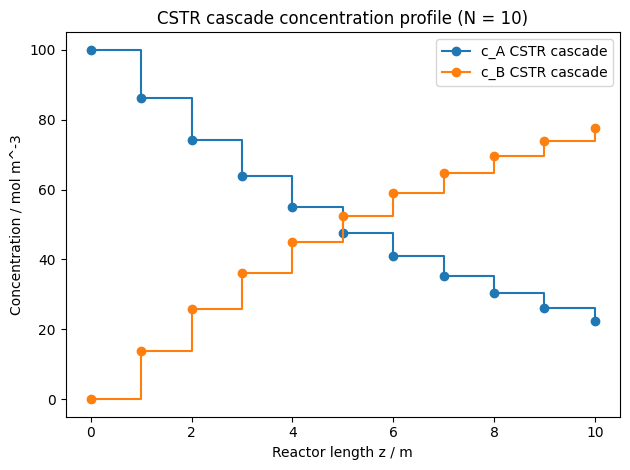

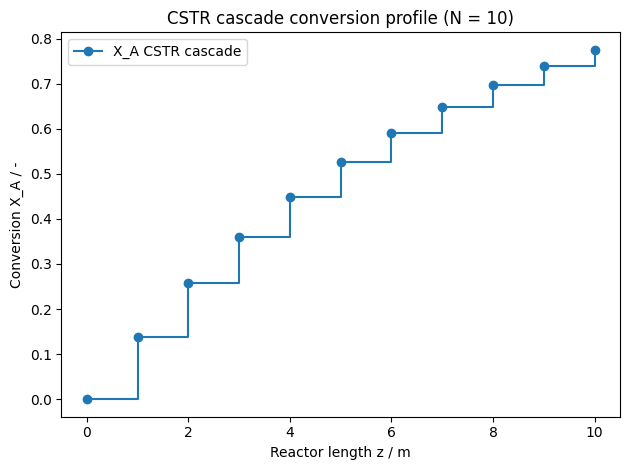

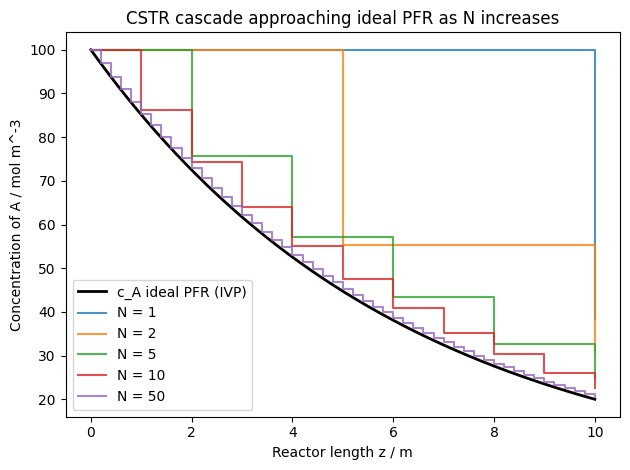

In [20]:
# CSTR cascade

# CSTR cascade model
def cstr_cascade(N, c_A_in, c_B_in, k, tau):
    """
    Steady-state CSTR cascade with N equal tanks, first-order kinetics.

    Returns arrays of c_A, c_B at the outlet of each tank (length N+1,
    including the feed as stage 0).
    """
    tau_i = tau / N

    c_A = np.zeros(N + 1)
    c_B = np.zeros(N + 1)
    c_A[0] = c_A_in
    c_B[0] = c_B_in

    for i in range(1, N + 1):
        c_A[i] = c_A[i-1] / (1 + k * tau_i)
        c_B[i] = c_B[i-1] + (c_A[i-1] - c_A[i])   # mass balance: whatever A lost, B gained

    return c_A, c_B

# Initial parameters for the CSTR cascade for first validation
N = 10
c_A_cascade, c_B_cascade = cstr_cascade(N, c_A_in, c_B_in, k, tau)

# Position each tank's outlet at its physical location along the reactor
z_cascade = np.linspace(0, L, N + 1)

# CSTR cascade concentration profile
plt.figure()
plt.step(
    z_cascade,
    c_A_cascade,
    where="post",
    marker="o",
    label="c_A CSTR cascade"
)
plt.step(
    z_cascade,
    c_B_cascade,
    where="post",
    marker="o",
    label="c_B CSTR cascade"
)
plt.xlabel("Reactor length z / m")
plt.ylabel("Concentration / mol m^-3")
plt.title(f"CSTR cascade concentration profile (N = {N})")
plt.legend()
plt.tight_layout()
plt.show()

# Conversion profile
X_A_cascade = conversion(c_A_cascade, c_A_in)

plt.figure()
plt.step(
    z_cascade,
    X_A_cascade,
    where="post",
    marker="o",
    label="X_A CSTR cascade"
)
plt.xlabel("Reactor length z / m")
plt.ylabel("Conversion X_A / -")
plt.title(f"CSTR cascade conversion profile (N = {N})")
plt.legend()
plt.tight_layout()
plt.show()

# Effect of N: cascade approaching plug-flow behaviour for high N
plt.figure()
plt.plot(
    pfr_df["z / m"],
    pfr_df["c_A / mol m^-3"],
    label="c_A ideal PFR (IVP)",
    color="black",
    linewidth=2
)

for N_i in [1, 2, 5, 10, 50]:
    c_A_i, _ = cstr_cascade(N_i, c_A_in, c_B_in, k, tau)
    z_i = np.linspace(0, L, N_i + 1)
    plt.step(
        z_i,
        c_A_i,
        where="post",
        label=f"N = {N_i}",
        alpha=0.8
    )

plt.xlabel("Reactor length z / m")
plt.ylabel("Concentration of A / mol m^-3")
plt.title("CSTR cascade approaching ideal PFR as N increases")
plt.legend()
plt.tight_layout()
plt.show()

## 11. Comparison of CSTR cascade with dispersion model at three distinct points

The assignment requires a comparison between the CSTR cascade and the axial-dispersion model at three distinct points along the reactor. In the code, this comparison is performed using:

$$
N = 10
$$

for the CSTR cascade and:

$$
Bo = 20
$$

for the axial-dispersion model.

The comparison is carried out at the following axial positions:

$$
z/L = 0.25,\ 0.50,\ 1.00
$$

These correspond to:

$$
z = 2.5\ \mathrm{m},\ 5.0\ \mathrm{m},\ 10.0\ \mathrm{m}
$$

The comparison results are:

| z / m | z/L | c_A dispersion / mol/m3 | c_A CSTR cascade / mol/m3 | Difference c_A / mol/m3 | X_A dispersion | X_A CSTR cascade | Difference X_A |
|---:|---:|---:|---:|---:|---:|---:|---:|
| 2.5 | 0.25 | 64.0000 | 69.0664 | 5.0664 | 0.3600 | 0.3093 | -0.0507 |
| 5.0 | 0.50 | 44.0249 | 47.4373 | 3.4125 | 0.5598 | 0.5256 | -0.0341 |
| 10.0 | 1.00 | 22.2823 | 22.5030 | 0.2207 | 0.7772 | 0.7750 | -0.0022 |

The CSTR cascade gives a higher concentration of A than the dispersion model at all three comparison points. Therefore, the conversion predicted by the CSTR cascade is lower than the conversion predicted by the dispersion model.

The largest difference occurs near the first comparison point at \(z/L = 0.25\). At this position, the CSTR cascade conversion is lower by about 0.0507. This happens because the CSTR cascade is represented by stepwise mixed zones. In each tank, the concentration is uniform, so the concentration profile changes discontinuously from one tank outlet to the next.

At \(z/L = 0.50\), the difference becomes smaller. The conversion difference is about 0.0341. At the reactor outlet, the difference is very small. The outlet conversion is 0.7772 for the dispersion model and 0.7750 for the CSTR cascade.

This shows that the two non-ideal reactor models are not identical along the full reactor length, but they can give similar outlet predictions when a suitable number of CSTRs and a suitable Bodenstein number are chosen. The axial-dispersion model gives a continuous concentration profile, while the CSTR cascade gives a stepwise concentration profile. Both models describe deviations from ideal plug flow, but they represent mixing in different mathematical ways.

Comparison of CSTR cascade with dispersion model at three distinct points:
 z / m  z/L / -  Bo dispersion / -  N CSTR / -  c_A dispersion / mol m^-3  c_A CSTR cascade / mol m^-3  Difference c_A / mol m^-3  c_B dispersion / mol m^-3  c_B CSTR cascade / mol m^-3  Difference c_B / mol m^-3  X_A dispersion / -  X_A CSTR cascade / -  Difference X_A / -
   2.5     0.25                 20          10                  63.999998                    69.066385                   5.066387                  36.000001                    30.933615                  -5.066387            0.360000              0.309336           -0.050664
   5.0     0.50                 20          10                  44.024871                    47.437340                   3.412468                  55.975128                    52.562660                  -3.412468            0.559751              0.525627           -0.034125
  10.0     1.00                 20          10                  22.282345                    22.5030

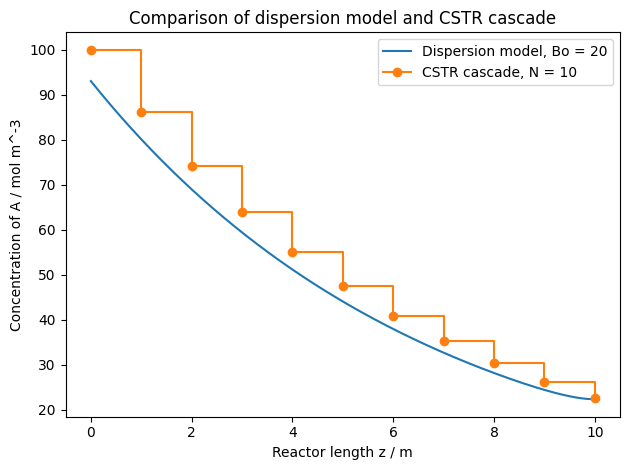

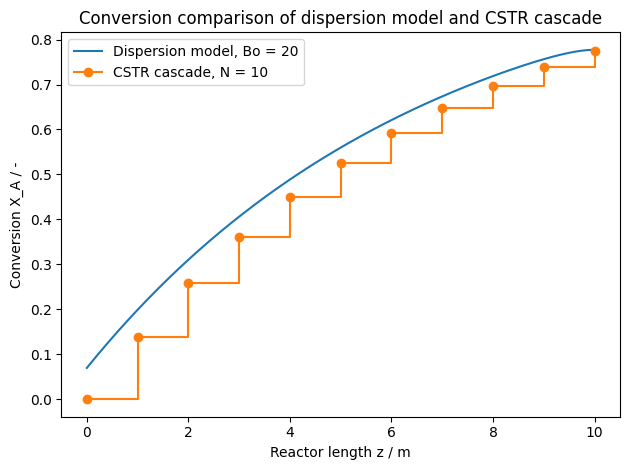

In [21]:
# Comparison of CSTR cascade with dispersion model at three distinct points

N_compare = 10
Bo_compare = 2 * N_compare

c_A_cascade_compare, c_B_cascade_compare = cstr_cascade(
    N_compare,
    c_A_in,
    c_B_in,
    k,
    tau
)

z_cascade_compare = np.linspace(0, L, N_compare + 1)
X_A_cascade_compare = conversion(c_A_cascade_compare, c_A_in)

if Bo_compare not in bo_results:
    D_ax_compare = u * L / Bo_compare

    z_mesh_compare = np.linspace(0, L, 300)

    c_A_guess = c_A_in * np.exp(-k * z_mesh_compare / u)
    dcA_dz_guess = -(k / u) * c_A_guess
    c_B_guess = c_B_in + c_A_in - c_A_guess
    dcB_dz_guess = -dcA_dz_guess

    y_guess_compare = np.vstack((c_A_guess, dcA_dz_guess, c_B_guess, dcB_dz_guess))

    sol_compare = solve_bvp(
        lambda z, y: dispersion_bvp_rhs(z, y, k, u, D_ax_compare),
        lambda ya, yb: dispersion_bc(ya, yb, c_A_in, c_B_in, u, D_ax_compare),
        z_mesh_compare,
        y_guess_compare,
        tol=1e-5,
        max_nodes=20000
    )

    if not sol_compare.success:
        raise RuntimeError(f"BVP failed for Bo = {Bo_compare}: {sol_compare.message}")

    z_compare = np.linspace(0, L, 500)
    y_compare = sol_compare.sol(z_compare)

    bo_results[Bo_compare] = {
        "solution": sol_compare,
        "D_ax": D_ax_compare,
        "z": z_compare,
        "c_A": y_compare[0],
        "dcA_dz": y_compare[1],
        "c_B": y_compare[2],
        "dcB_dz": y_compare[3],
        "X_A": conversion(y_compare[0], c_A_in),
        "J_disp_A": -D_ax_compare * y_compare[1]
    }

comparison_positions = [0.25 * L, 0.50 * L, L]
cstr_dispersion_comparison_records = []

for z_pos in comparison_positions:
    c_A_disp_pos = np.interp(
        z_pos,
        bo_results[Bo_compare]["z"],
        bo_results[Bo_compare]["c_A"]
    )

    c_B_disp_pos = np.interp(
        z_pos,
        bo_results[Bo_compare]["z"],
        bo_results[Bo_compare]["c_B"]
    )

    X_A_disp_pos = np.interp(
        z_pos,
        bo_results[Bo_compare]["z"],
        bo_results[Bo_compare]["X_A"]
    )

    c_A_cstr_pos = np.interp(
        z_pos,
        z_cascade_compare,
        c_A_cascade_compare
    )

    c_B_cstr_pos = np.interp(
        z_pos,
        z_cascade_compare,
        c_B_cascade_compare
    )

    X_A_cstr_pos = np.interp(
        z_pos,
        z_cascade_compare,
        X_A_cascade_compare
    )

    cstr_dispersion_comparison_records.append({
        "z / m": z_pos,
        "z/L / -": z_pos / L,
        "Bo dispersion / -": Bo_compare,
        "N CSTR / -": N_compare,
        "c_A dispersion / mol m^-3": c_A_disp_pos,
        "c_A CSTR cascade / mol m^-3": c_A_cstr_pos,
        "Difference c_A / mol m^-3": c_A_cstr_pos - c_A_disp_pos,
        "c_B dispersion / mol m^-3": c_B_disp_pos,
        "c_B CSTR cascade / mol m^-3": c_B_cstr_pos,
        "Difference c_B / mol m^-3": c_B_cstr_pos - c_B_disp_pos,
        "X_A dispersion / -": X_A_disp_pos,
        "X_A CSTR cascade / -": X_A_cstr_pos,
        "Difference X_A / -": X_A_cstr_pos - X_A_disp_pos
    })

cstr_dispersion_comparison_df = pd.DataFrame(cstr_dispersion_comparison_records)

print("Comparison of CSTR cascade with dispersion model at three distinct points:")
print(cstr_dispersion_comparison_df.to_string(index=False))

# Plot comparison of c_A profiles
plt.figure()
plt.plot(
    bo_results[Bo_compare]["z"],
    bo_results[Bo_compare]["c_A"],
    label=f"Dispersion model, Bo = {Bo_compare}"
)
plt.step(
    z_cascade_compare,
    c_A_cascade_compare,
    where="post",
    marker="o",
    label=f"CSTR cascade, N = {N_compare}"
)
plt.xlabel("Reactor length z / m")
plt.ylabel("Concentration of A / mol m^-3")
plt.title("Comparison of dispersion model and CSTR cascade")
plt.legend()
plt.tight_layout()
plt.show()

# Plot comparison of conversion profiles
plt.figure()
plt.plot(
    bo_results[Bo_compare]["z"],
    bo_results[Bo_compare]["X_A"],
    label=f"Dispersion model, Bo = {Bo_compare}"
)
plt.step(
    z_cascade_compare,
    X_A_cascade_compare,
    where="post",
    marker="o",
    label=f"CSTR cascade, N = {N_compare}"
)
plt.xlabel("Reactor length z / m")
plt.ylabel("Conversion X_A / -")
plt.title("Conversion comparison of dispersion model and CSTR cascade")
plt.legend()
plt.tight_layout()
plt.show()

Final model comparison summary:
               Model     Parameter  c_A,out / mol m^-3  c_B,out / mol m^-3  X_A,out / -
       Ideal PFR IVP Bo = infinity           20.018858           79.981142     0.799811
Axial-dispersion BVP        Bo = 5           26.634107           73.365893     0.733659
Axial-dispersion BVP       Bo = 20           22.282345           77.717655     0.777177
Axial-dispersion BVP      Bo = 100           20.522135           79.477865     0.794779
Axial-dispersion BVP    Bo = 10000           20.024036           79.975964     0.799760
        CSTR cascade         N = 1           38.336276           61.663724     0.616637
        CSTR cascade         N = 2           30.719042           69.280958     0.692810
        CSTR cascade         N = 5           24.793455           75.206545     0.752065
        CSTR cascade        N = 10           22.503012           77.496988     0.774970
        CSTR cascade        N = 50           20.532428           79.467572     0.794676


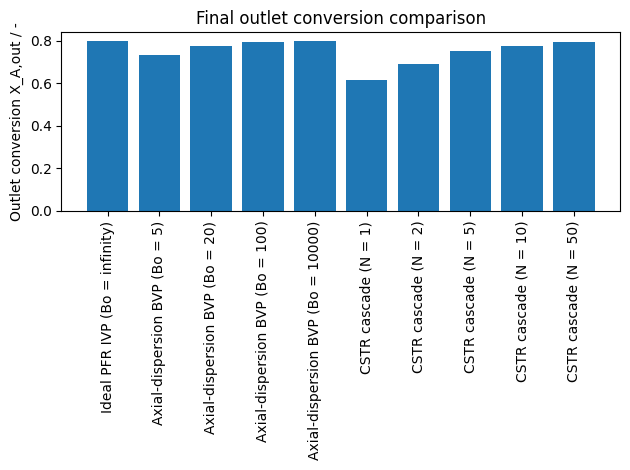

In [22]:
# Final summary table

final_summary_records = []

final_summary_records.append({
    "Model": "Ideal PFR IVP",
    "Parameter": "Bo = infinity",
    "c_A,out / mol m^-3": pfr_df["c_A / mol m^-3"].iloc[-1],
    "c_B,out / mol m^-3": pfr_df["c_B / mol m^-3"].iloc[-1],
    "X_A,out / -": pfr_df["X_A / -"].iloc[-1]
})

for Bo in [5, 20, 100, 10000]:
    if Bo in bo_results:
        final_summary_records.append({
            "Model": "Axial-dispersion BVP",
            "Parameter": f"Bo = {Bo:g}",
            "c_A,out / mol m^-3": bo_results[Bo]["c_A"][-1],
            "c_B,out / mol m^-3": bo_results[Bo]["c_B"][-1],
            "X_A,out / -": bo_results[Bo]["X_A"][-1]
        })

for N_i in [1, 2, 5, 10, 50]:
    c_A_i, c_B_i = cstr_cascade(N_i, c_A_in, c_B_in, k, tau)
    X_A_i = conversion(c_A_i, c_A_in)

    final_summary_records.append({
        "Model": "CSTR cascade",
        "Parameter": f"N = {N_i}",
        "c_A,out / mol m^-3": c_A_i[-1],
        "c_B,out / mol m^-3": c_B_i[-1],
        "X_A,out / -": X_A_i[-1]
    })

final_summary_df = pd.DataFrame(final_summary_records)

print("Final model comparison summary:")
print(final_summary_df.to_string(index=False))

# Final outlet conversion comparison plot
plt.figure()

plot_labels = final_summary_df["Model"] + " (" + final_summary_df["Parameter"] + ")"

plt.bar(
    np.arange(len(final_summary_df)),
    final_summary_df["X_A,out / -"]
)

plt.xticks(
    np.arange(len(final_summary_df)),
    plot_labels,
    rotation=90
)

plt.ylabel("Outlet conversion X_A,out / -")
plt.title("Final outlet conversion comparison")
plt.tight_layout()
plt.show()

## 12. Industrial Relevance

Tubular plug flow reactors are a common type of continuous reactor used in industries producing chemicals and petrochemicals. Their high conversion rate, narrow residence time distribution and heat transfer efficiency make them ideal for use. A large surface area to volume ratio also makes them suitable for highly exothermic or endothermic reactions under high pressure. Due to simple design, scaling up the reactor and integrating into large-scale industrial production system becomes managable [3].

Industrial applications of plug flow reactors are evident in commercial processes such as steam cracking hydrocarbons for olefin production, vinyl chloride production, high-pressure polyethylene production, gas phase halogenation, hydrogen cyanide production, ketene production and ethylene glycol production from ethylene oxide hydrolysis. Concentration, temperature and residence time profiles are crucial for achieving high-quality products, efficient processes and safe reactor operation in these applications [3].

Besides the renowned industrial applications, PFRs are also used to develop new processes and their optimization. A study on production of cumene by catalytic alkylation of propylene and benzene in a plug flow reactor has been conducted. A study showcases PFRs' sustainability and cost-effectiveness for large-scale chemical production, due to high conversion rates, efficient operation, and compact size when combined with mass and energy balances and steady-state reactor modeling [4].

## Conclusion

The non-ideal flow behaviour of a tubular reactor was investigated in this work with the application of the axial dispersion model. Numerical analysis enabled understanding of the effect of axial mixing on the concentration profiles and the reactor performance. The comparison of the axial dispersion model to the equivalent CSTR cascade also highlighted alternative ways to model non-ideal flow in tubular reactors.

Results show that the Bodenstein number (Bo) plays a major role in the behavior of the reactors. Higher values of the Bodenstein numbers bring the reactor closer to ideal plug flow conditions, which decrease axial mixing. However, lower values correspond to higher levels of backmixing, wider residence time distributions and larger deviations from the ideal PFR behavior. 

In conclusion, this study highlights that non-ideal flow effects need to be taken into account when modeling tubular reactors. The model of axial dispersion provides a realistic and reliable method for the prediction of reactor performance. It is an important tool for design, optimization and scale-up of reactors. The understanding of axial dispersion and the Bodenstein number helps engineers to have a better assessment of reactor performance and can design more efficient reactor systems for industry.

## References

[1] R. Güttel and T. Turek, *Chemische Reaktionstechnik*, 1st ed.
Berlin, Germany: Springer Spektrum, 2021.
DOI: https://doi.org/10.1007/978-3-662-63150-8

[2] P. V. Danckwerts, "Continuous flow systems: Distribution of residence times,"
*Chemical Engineering Science*, vol. 2, no. 1, pp. 1–13, 1953.
DOI: https://doi.org/10.1016/0009-2509(53)80001-1

[3] J. Sauer, N. Dahmen, and E. Henrich, *Tubular Plug Flow Reactors*, in *Ullmann's Encyclopedia of Industrial Chemistry*.
Weinheim, Germany: Wiley-VCH, 2013.
DOI: https://doi.org/10.1002/14356007.b04_181.pub2

[4] C. O. Wosu, "Plug Flow Reactor (PFR) Design for the Production of 100,000 Tons per Year of Cumene from the Catalytic Alkylation of Propylene and Benzene,"
*Journal of Engineering Research Innovation and Scientific Development*, vol. 2, no. 2, pp. 24–33, 2024.
DOI: https://doi.org/10.61448/JERISD22244

## AI Use

**1. Tools used**

Claude Sonnet 5 , July 2026\
ChatGPT, July 2026\
GitHub Copilot in VS Code, July 2026

**2. Areas of use**

| Subtask | AI |
|---|---|
| Code debugging | Yes |
| Code generation | Yes |
| Concept explanation | Yes |
| Language editing of report | Yes |
| Text generation | No |
| Logic | No |

**3. Prompting strategy**

A usual prompt has the following structure:
1) Current state. This might include current code, an error message or a description of a certain task.
2) Own Idea. This might include possible functions to use, a certain logic to follow or may be skipped in case of an error message.
3) Task. What the AI should do. This may include error solving, code generation in a certain logic or explanation of functions or concepts.

**4. Critical examination**

All AI outputs are always read carefully and not copied blindly.
Any output that is not explicitly asked for is not used.


**5. Statement of own contribution**

The building of the correct equations, the verification of the logic behind the calculations and the results and the scientific interpretation of those are the group's independent work. AI was used as a coding and explanation tool and all conclusions in this report were formulated by the group.


### Author Contribution

All authors contributed equally.